In [43]:
import pandas as pd

df = pd.read_csv('fitts_study_exp.csv')
df.head()

,idx,target_size,target_distance,reaction_time
0,0,20.000000,0.00000,2054.0
1,1,16.710438,463.14532,930.0
2,2,28.997887,198.25008,666.0
3,3,33.769592,526.47660,782.0
4,4,27.093876,599.32056,1132.0


In [44]:
# compute difficulty based on fitts law

import numpy as np

df["difficulty"] = np.log2((df["target_distance"] / df["target_size"])) 

df.head()

/Users/namwoam/rep/mhci/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


,idx,target_size,target_distance,reaction_time,difficulty
0,0,20.000000,0.00000,2054.0,-inf
1,1,16.710438,463.14532,930.0,4.792643
2,2,28.997887,198.25008,666.0,2.773302
3,3,33.769592,526.47660,782.0,3.962573
4,4,27.093876,599.32056,1132.0,4.467289


In [45]:
# remove outliers based on reaction time
df = df[df["reaction_time"] < 1500]

Text(0.5, 1.0, 'Difficulty vs Reaction Time')

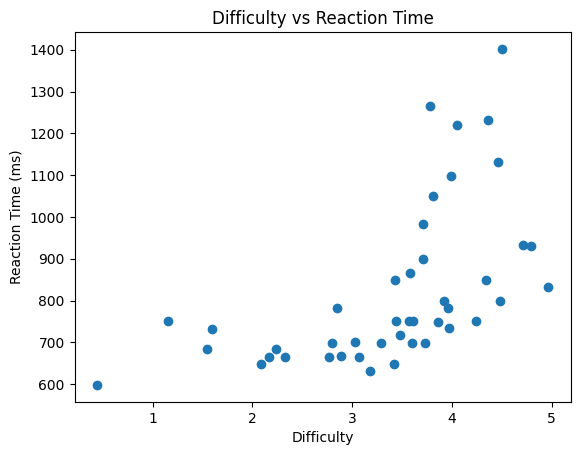

In [46]:
# plot scatter plot of difficulty vs movement time

import matplotlib.pyplot as plt
plt.scatter(df["difficulty"], df["reaction_time"])
plt.xlabel("Difficulty")
plt.ylabel("Reaction Time (ms)")
plt.title("Difficulty vs Reaction Time")

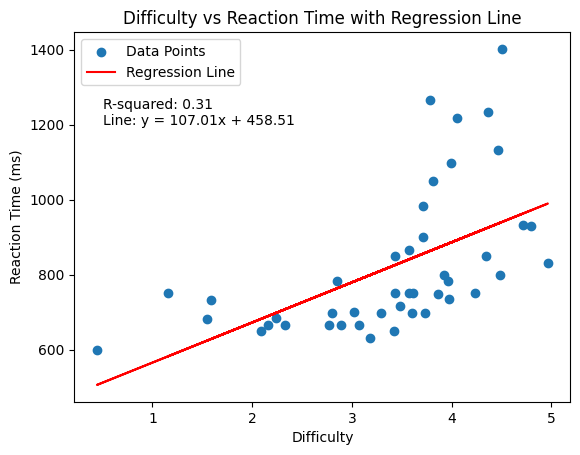

In [47]:
# plot linear regression line
from scipy import stats
slope, intercept, r_value, p_value, std_err = stats.linregress(df["difficulty"], df["reaction_time"])
# plot regression line and scatter plot together
plt.scatter(df["difficulty"], df["reaction_time"], label="Data Points")
plt.plot(df["difficulty"], intercept + slope*df["difficulty"], 'r', label="Regression Line")
plt.xlabel("Difficulty")
plt.ylabel("Reaction Time (ms)")
plt.title("Difficulty vs Reaction Time with Regression Line")
plt.legend()

# show R-squared value and line equation on the plot
plt.text(0.5, 1200, f'R-squared: {r_value**2:.2f}\nLine: y = {slope:.2f}x + {intercept:.2f}', fontsize=10)
plt.show()